# FAPE, SBA Agricultural Loans EDA
## Agriculture/Financial Domain, Loan Default Analysis

**Dataset:** SBA 7(a) Agricultural Loans, NAICS-11 filter, FY1991-2024  
**Records:** 15,845  
**Target:** loan_default_binary (1=Charged Off, 0=Paid In Full)  
**Sensitive attributes:** borrstate (geographic proxy), businesstype  
**Domain:** Agriculture/Financial  

**Important note:** SBA FOIA data contains no race/ethnicity/sex fields, redacted per SBA privacy policy. Geographic and business structure proxies used per ECOA fair lending standard.

**Key finding:** Individual farmers bore highest default burden during 2000s financial crisis (11.8%). Louisiana shows 14.4% default rate, highest geographic rate, likely Hurricane Katrina impact.

In [1]:
import sys
import os
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sba_agricultural_loader import load_sba_agricultural

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
os.makedirs('../figures/eda', exist_ok=True)

BTYPE_LABELS = {-1:'Unknown', 0:'Corporation', 1:'Individual', 2:'Partnership'}
STATE_MAP = {0:'AK',1:'AL',2:'AR',3:'AZ',4:'CA',5:'CO',6:'CT',7:'DC',8:'DE',
9:'FL',10:'GA',11:'GU',12:'HI',13:'IA',14:'ID',15:'IL',16:'IN',17:'KS',18:'KY',
19:'LA',20:'MA',21:'MD',22:'ME',23:'MI',24:'MN',25:'MO',26:'MP',27:'MS',28:'MT',
29:'NC',30:'ND',31:'NE',32:'NH',33:'NJ',34:'NM',35:'NV',36:'NY',37:'OH',38:'OK',
39:'OR',40:'PA',41:'PR',42:'RI',43:'SC',44:'SD',45:'TN',46:'TX',47:'UT',48:'VA',
49:'VI',50:'VT',51:'WA',52:'WI',53:'WV',54:'WY'}
print('Imports complete')

Imports complete


In [2]:
dataset = load_sba_agricultural(data_dir='../data/raw/agricultural/sba_loans')
data = dataset['sba_agricultural']
df = pd.concat([data['X'], data['y']], axis=1)
df.columns = list(data['X'].columns) + ['label']
df['btype_name'] = df['businesstype'].map(BTYPE_LABELS)
df['state_name'] = df['borrstate'].map(STATE_MAP)
df['decade'] = (df['approvalfy'] // 10 * 10).astype(int)
print(f'Shape: {df.shape}')
print(f'Default rate: {df["label"].mean():.1%}')
print(f'Records: {len(df):,}')

Loading SBA 7(a) agricultural loans FY1991-2024...


  FY1991-1999: 337,033 total | 4,445 agricultural NAICS-11


  FY2000-2009: 690,333 total | 4,931 agricultural NAICS-11


  FY2010-2019: 545,751 total | 8,632 agricultural NAICS-11


  FY2020-Present: 373,981 total | 3,918 agricultural NAICS-11
  Combined agricultural records: 21,926
  After binary outcome filter: 15,845

  Loan status distribution:
    Paid In Full: 15,015
    Charged Off:  830

  Top agricultural NAICS categories:
naicsdescription
Broilers and Other Meat Type Chicken Production     6335
Logging                                             1756
Support Activities for Animal Production            1097
Chicken Egg Production                               946
Broilers and Other Meat Type Chicken Production      853

  OK: sba_agricultural: 15,845 records | 8 features | default rate: 0.052
Shape: (15845, 12)
Default rate: 5.2%
Records: 15,845


## 1. Label Distribution, 5.2% Default Rate

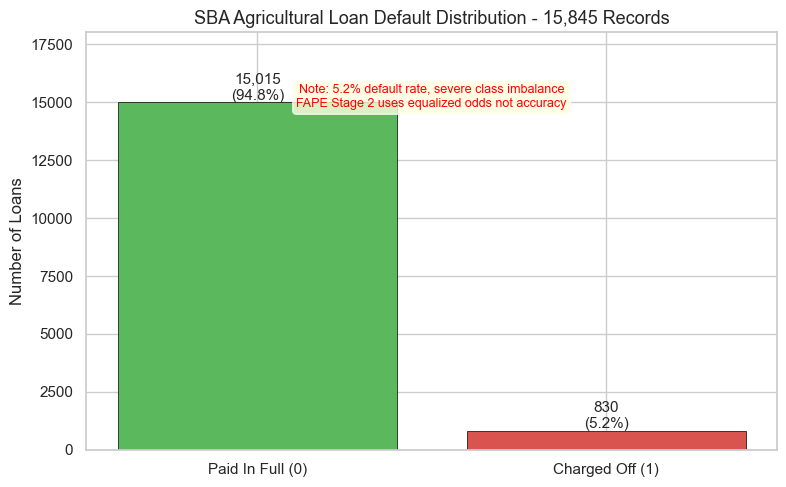

In [3]:
label_counts = df['label'].value_counts().sort_index()
label_pct = df['label'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(['Paid In Full (0)','Charged Off (1)'], label_counts.values,
              color=['#5cb85c','#d9534f'], edgecolor='black', linewidth=0.5)
for bar, val, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
            f'{val:,}\n({pct:.1%})', ha='center', fontsize=11)
ax.set_title('SBA Agricultural Loan Default Distribution - 15,845 Records', fontsize=13)
ax.set_ylabel('Number of Loans')
ax.set_ylim(0, max(label_counts.values)*1.2)
ax.text(0.5, 0.82, 'Note: 5.2% default rate, severe class imbalance\nFAPE Stage 2 uses equalized odds not accuracy',
        transform=ax.transAxes, ha='center', fontsize=9, color='red',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.savefig('../figures/eda/agricultural_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Business Type vs Default Rate

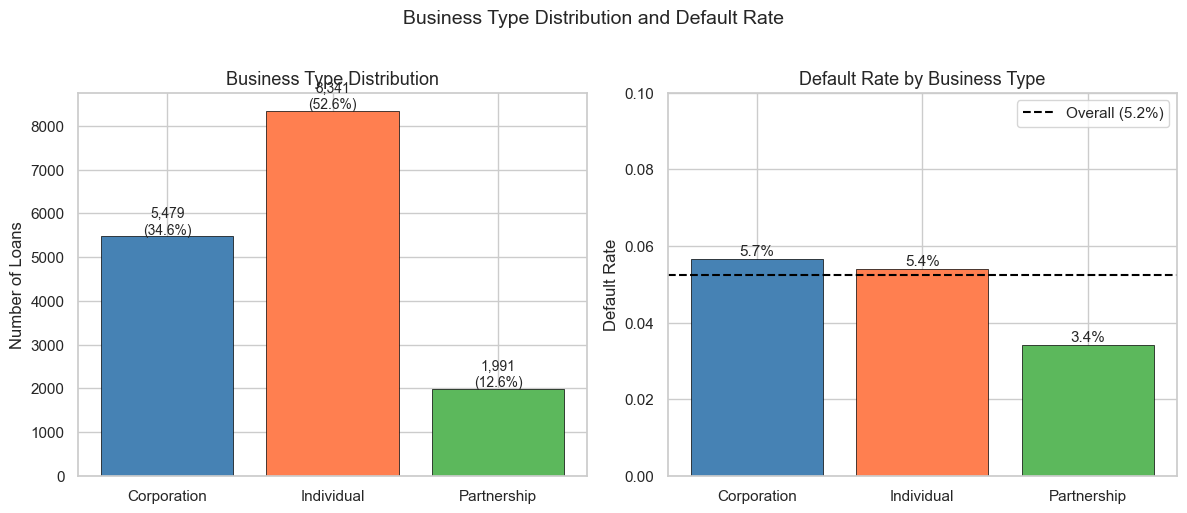

Partnership has lowest default rate (3.4%), typically larger, more established operations


In [4]:
btype_stats = df[df['businesstype']>=0].groupby('btype_name').agg(
    count=('label','count'), default_rate=('label','mean')).reset_index()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
colors = ['steelblue','coral','#5cb85c']

ax1.bar(btype_stats['btype_name'], btype_stats['count'], color=colors, edgecolor='black', linewidth=0.5)
ax1.set_title('Business Type Distribution', fontsize=13)
ax1.set_ylabel('Number of Loans')
for i, (_, row) in enumerate(btype_stats.iterrows()):
    ax1.text(i, row['count']+50, f'{int(row["count"]):,}\n({row["count"]/len(df):.1%})', ha='center', fontsize=10)

ax2.bar(btype_stats['btype_name'], btype_stats['default_rate'], color=colors, edgecolor='black', linewidth=0.5)
ax2.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Overall ({df["label"].mean():.1%})')
ax2.set_title('Default Rate by Business Type', fontsize=13)
ax2.set_ylabel('Default Rate')
ax2.set_ylim(0, 0.1)
ax2.legend()
for i, (_, row) in enumerate(btype_stats.iterrows()):
    ax2.text(i, row['default_rate']+0.001, f'{row["default_rate"]:.1%}', ha='center', fontsize=11)

plt.suptitle('Business Type Distribution and Default Rate', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/agricultural_business_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Partnership has lowest default rate (3.4%), typically larger, more established operations')

## 3. Geographic Distribution, Top 15 States

Note: Louisiana shows 14.4% default rate, likely Hurricane Katrina impact on 2000s loans. Mississippi dominates (n=3,670) due to poultry farming concentration.

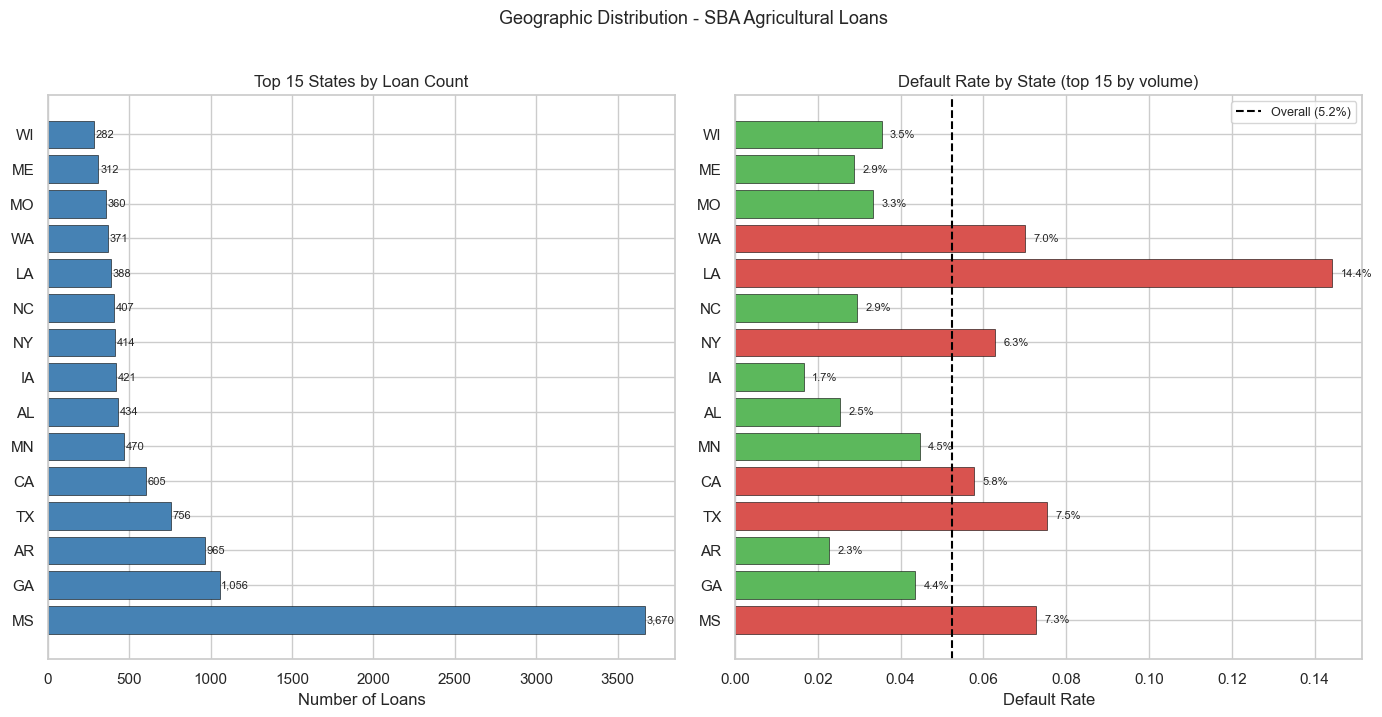

LA default rate: 14.4%, highest among top 15 states


In [5]:
state_stats = df.groupby('state_name').agg(
    count=('label','count'), default_rate=('label','mean')).reset_index()
top15 = state_stats.nlargest(15, 'count')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,7))

ax1.barh(top15['state_name'], top15['count'], color='steelblue', edgecolor='black', linewidth=0.4)
ax1.set_title('Top 15 States by Loan Count', fontsize=12)
ax1.set_xlabel('Number of Loans')
for i, (_, row) in enumerate(top15.iterrows()):
    ax1.text(row['count']+10, i, f'{int(row["count"]):,}', va='center', fontsize=8)

colors = ['#d9534f' if r > df['label'].mean() else '#5cb85c' for r in top15['default_rate']]
ax2.barh(top15['state_name'], top15['default_rate'], color=colors, edgecolor='black', linewidth=0.4)
ax2.axvline(x=df['label'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Overall ({df["label"].mean():.1%})')
ax2.set_title('Default Rate by State (top 15 by volume)', fontsize=12)
ax2.set_xlabel('Default Rate')
ax2.legend(fontsize=9)
for i, (_, row) in enumerate(top15.iterrows()):
    ax2.text(row['default_rate']+0.002, i, f'{row["default_rate"]:.1%}', va='center', fontsize=8)

plt.suptitle('Geographic Distribution - SBA Agricultural Loans', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/agricultural_geographic.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'LA default rate: {df[df["state_name"]=="LA"]["label"].mean():.1%}, highest among top 15 states')

## 4. Loan Amount Distribution by Default Status

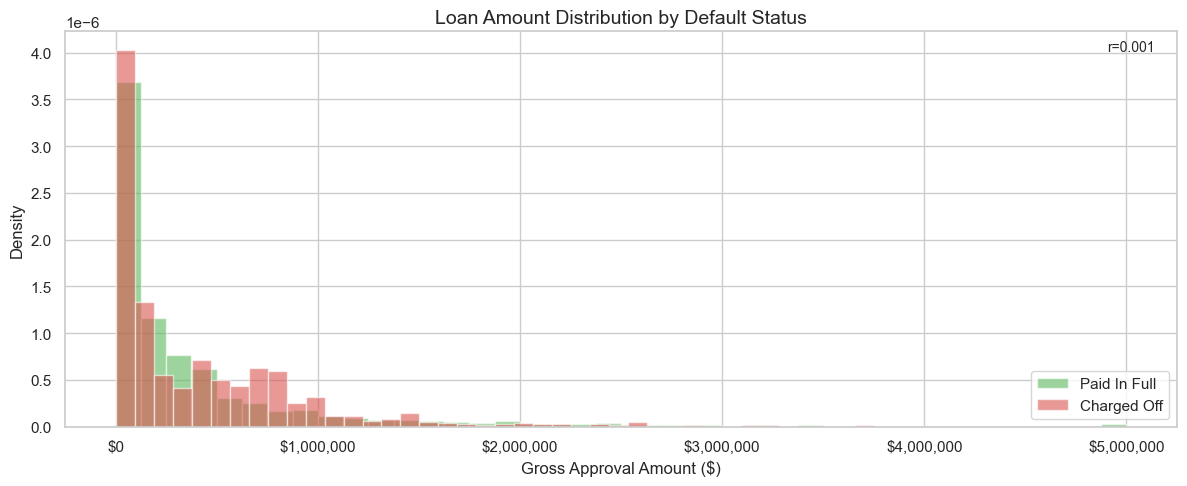

Paid mean: $406,149 | Default mean: $410,038
Near-zero correlation (r=0.001), loan size is not predictive of default in agricultural loans


In [6]:
fig, ax = plt.subplots(figsize=(12,5))
ax.hist(df[df['label']==0]['grossapproval'], bins=40, alpha=0.6, color='#5cb85c', label='Paid In Full', density=True)
ax.hist(df[df['label']==1]['grossapproval'], bins=40, alpha=0.6, color='#d9534f', label='Charged Off', density=True)
ax.set_title('Loan Amount Distribution by Default Status', fontsize=14)
ax.set_xlabel('Gross Approval Amount ($)')
ax.set_ylabel('Density')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${int(x):,}'))
ax.legend()
corr = df['grossapproval'].corr(df['label'])
ax.text(0.98, 0.95, f'r={corr:.3f}', transform=ax.transAxes, fontsize=10, ha='right')
plt.tight_layout()
plt.savefig('../figures/eda/agricultural_loan_amount.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Paid mean: ${df[df["label"]==0]["grossapproval"].mean():,.0f} | Default mean: ${df[df["label"]==1]["grossapproval"].mean():,.0f}')
print('Near-zero correlation (r=0.001), loan size is not predictive of default in agricultural loans')

## 5. Loan Term vs Default Rate

Standard terms (60-300 months) show very low default rates. Non-standard and legacy terms drive the overall 5.2% rate.

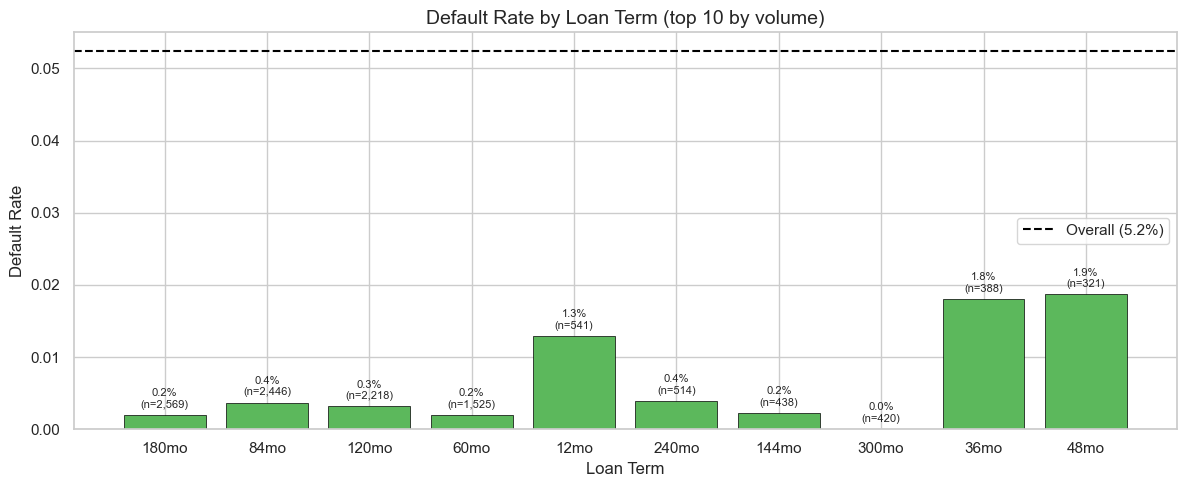

In [7]:
term_stats = df.groupby('terminmonths').agg(
    count=('label','count'), default_rate=('label','mean')).reset_index()
term_stats = term_stats.sort_values('count', ascending=False).head(10)
term_labels = [f'{int(t)}mo' for t in term_stats['terminmonths']]

fig, ax = plt.subplots(figsize=(12,5))
colors = ['#d9534f' if r > df['label'].mean() else '#5cb85c' for r in term_stats['default_rate']]
bars = ax.bar(term_labels, term_stats['default_rate'], color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Overall ({df["label"].mean():.1%})')
ax.set_title('Default Rate by Loan Term (top 10 by volume)', fontsize=14)
ax.set_xlabel('Loan Term')
ax.set_ylabel('Default Rate')
ax.legend()
for bar, (_, row) in zip(bars, term_stats.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{row["default_rate"]:.1%}\n(n={int(row["count"]):,})', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/eda/agricultural_loan_term.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Approval Decade vs Default Rate

2000s financial crisis drove highest agricultural loan default rate (10.9%). Recovery visible in 2010s (4.2%).

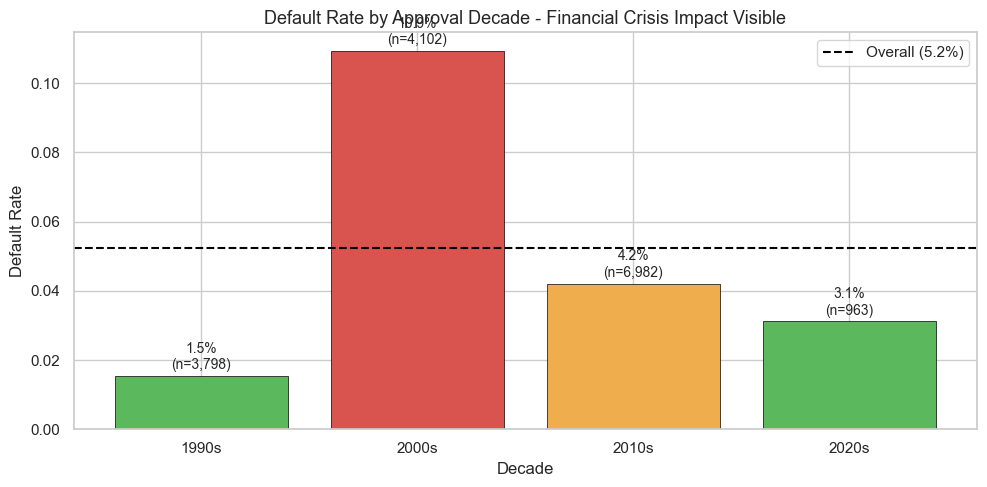

In [8]:
decade_stats = df.groupby('decade').agg(
    count=('label','count'), default_rate=('label','mean')).reset_index()
decade_labels = [f'{int(d)}s' for d in decade_stats['decade']]

fig, ax = plt.subplots(figsize=(10,5))
colors = ['#5cb85c','#d9534f','#f0ad4e','#5cb85c']
bars = ax.bar(decade_labels, decade_stats['default_rate'], color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Overall ({df["label"].mean():.1%})')
ax.set_title('Default Rate by Approval Decade - Financial Crisis Impact Visible', fontsize=13)
ax.set_xlabel('Decade')
ax.set_ylabel('Default Rate')
ax.legend()
for bar, (_, row) in zip(bars, decade_stats.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{row["default_rate"]:.1%}\n(n={int(row["count"]):,})', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/eda/agricultural_decade.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. NAICS Agricultural Subcategory vs Default Rate

Note: Shellfish Fishing shows 30.0% default rate, highest subcategory default. Broilers dominate by volume (n=5,128).

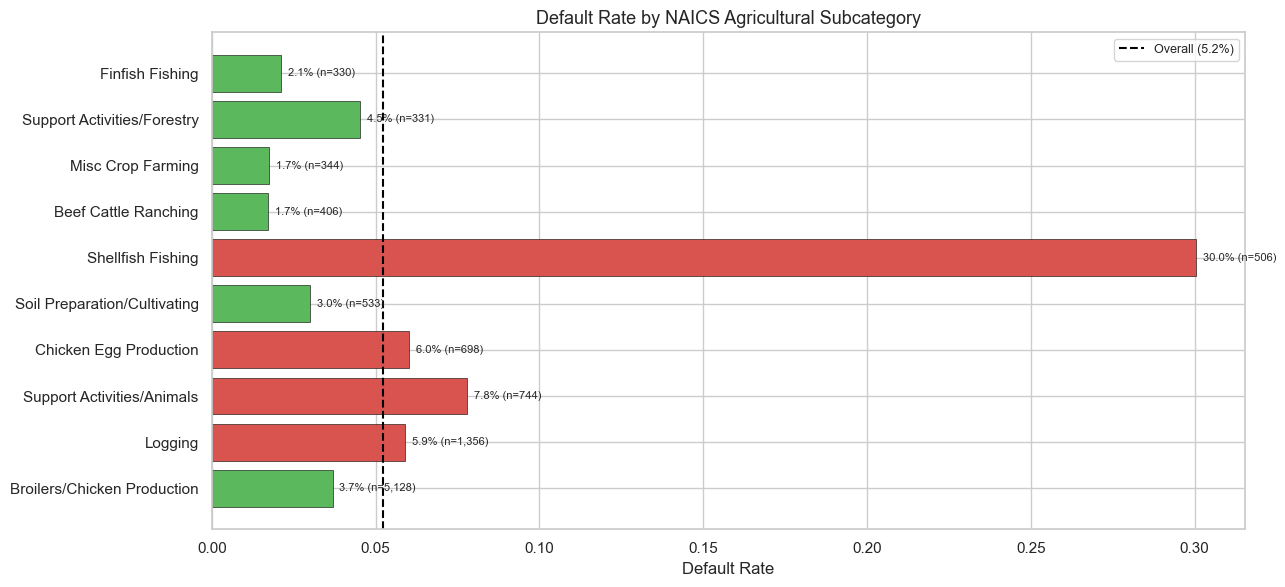

Shellfish Fishing: 30.0% default, highest subcategory
Broilers/Chicken Production: 3.7% default, largest volume, below average risk


In [9]:
NAICS_MAP = {
    16:'Broilers/Chicken Production', 60:'Logging', 102:'Support Activities/Animals',
    20:'Chicken Egg Production', 95:'Soil Preparation/Cultivating',
    93:'Shellfish Fishing', 11:'Beef Cattle Ranching', 6:'Misc Crop Farming',
    103:'Support Activities/Forestry', 41:'Finfish Fishing'
}

naics_stats = df.groupby('naicsdescription').agg(
    count=('label','count'), default_rate=('label','mean')).reset_index()
naics_stats['naics_name'] = naics_stats['naicsdescription'].apply(
    lambda x: NAICS_MAP.get(int(x), f'NAICS_{int(x)}'))
# Filter out trailing-space duplicates, keep only mapped ones
naics_plot = naics_stats[naics_stats['naicsdescription'].isin(NAICS_MAP.keys())].sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(13,6))
colors = ['#d9534f' if r > df['label'].mean() else '#5cb85c' for r in naics_plot['default_rate']]
bars = ax.barh(naics_plot['naics_name'], naics_plot['default_rate'],
               color=colors, edgecolor='black', linewidth=0.4)
ax.axvline(x=df['label'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Overall ({df["label"].mean():.1%})')
ax.set_title('Default Rate by NAICS Agricultural Subcategory', fontsize=13)
ax.set_xlabel('Default Rate')
ax.legend(fontsize=9)
for bar, (_, row) in zip(bars, naics_plot.iterrows()):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            f'{row["default_rate"]:.1%} (n={int(row["count"]):,})', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/eda/agricultural_naics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Shellfish Fishing: 30.0% default, highest subcategory')
print('Broilers/Chicken Production: 3.7% default, largest volume, below average risk')

## 8. Jobs Supported Distribution

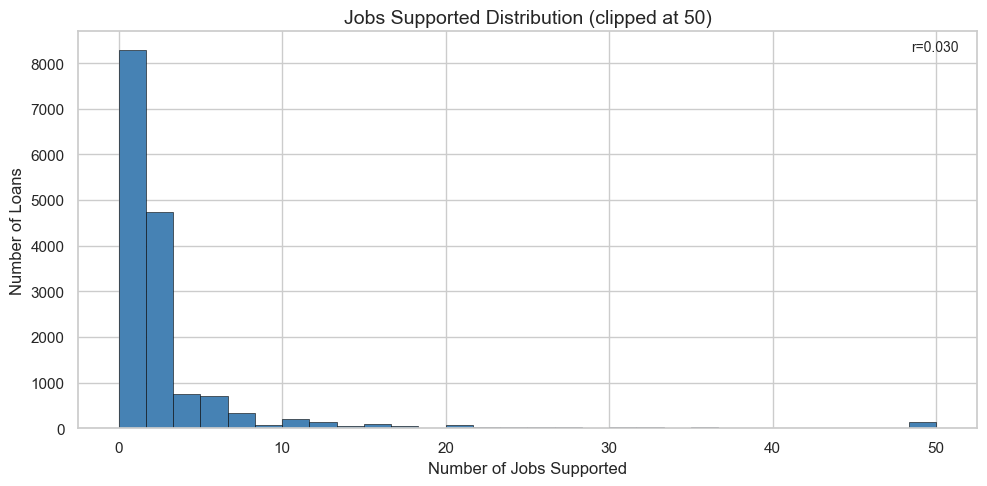

Mean jobs: 3.5 | Median: 1
Jobs-default correlation: 0.030, weak predictor


In [10]:
jobs_valid = df[df['jobssupported'] >= 0]['jobssupported'].clip(upper=50)

fig, ax = plt.subplots(figsize=(10,5))
ax.hist(jobs_valid, bins=30, color='steelblue', edgecolor='black', linewidth=0.4)
ax.set_title('Jobs Supported Distribution (clipped at 50)', fontsize=14)
ax.set_xlabel('Number of Jobs Supported')
ax.set_ylabel('Number of Loans')
corr = df['jobssupported'].corr(df['label'])
ax.text(0.98, 0.95, f'r={corr:.3f}', transform=ax.transAxes, fontsize=10, ha='right')
plt.tight_layout()
plt.savefig('../figures/eda/agricultural_jobs.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean jobs: {df[df["jobssupported"]>=0]["jobssupported"].mean():.1f} | Median: {df[df["jobssupported"]>=0]["jobssupported"].median():.0f}')
print(f'Jobs-default correlation: {corr:.3f}, weak predictor')

## 9. Decade × Business Type Interaction, Key Fairness Finding

Individual farmers bore the highest default burden during the 2000s financial crisis (11.8%). Partnerships were most protected (8.6%). This asymmetry is a fairness-relevant finding, individual farmers have the least financial cushion and fewest legal protections.

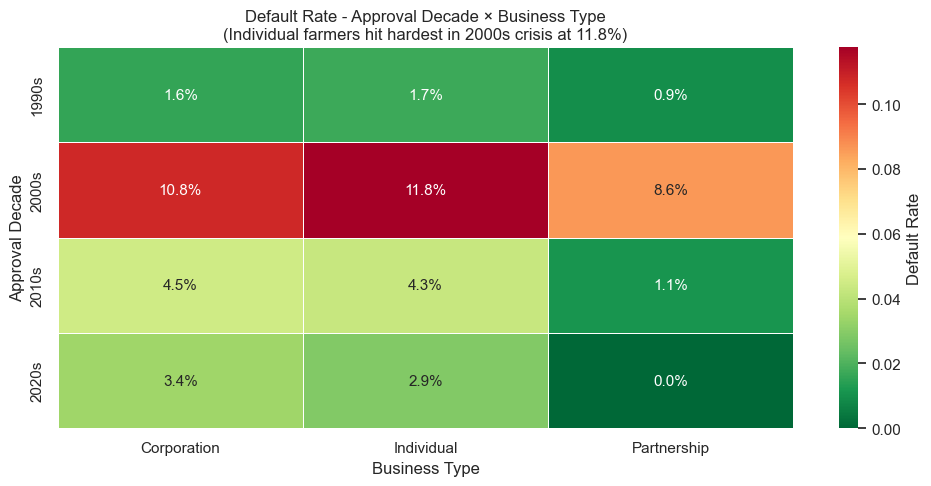

2000s: Individual 11.8% > Corporation 10.8% > Partnership 8.6%
Individual farmers most vulnerable to macroeconomic shocks


In [11]:
pivot = df[df['businesstype']>=0].groupby(['decade','btype_name'])['label'].mean().unstack()

fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, cbar_kws={'label':'Default Rate'})
ax.set_title('Default Rate - Approval Decade × Business Type\n'
             '(Individual farmers hit hardest in 2000s crisis at 11.8%)', fontsize=12)
ax.set_xlabel('Business Type')
ax.set_ylabel('Approval Decade')
ax.set_yticklabels([f'{int(d.get_text())}s' if d.get_text().isdigit() else d.get_text() for d in ax.get_yticklabels()])
plt.tight_layout()
plt.savefig('../figures/eda/agricultural_decade_btype.png', dpi=150, bbox_inches='tight')
plt.show()
print('2000s: Individual 11.8% > Corporation 10.8% > Partnership 8.6%')
print('Individual farmers most vulnerable to macroeconomic shocks')

## 10. Feature Correlations with Default Label

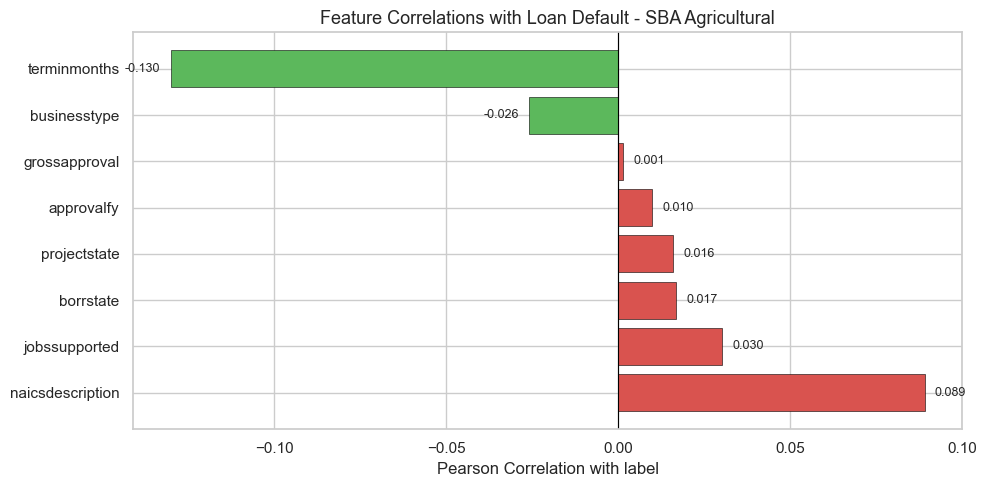

terminmonths strongest negative predictor (r=-0.130)
naicsdescription strongest positive predictor (r=0.089), subcategory matters


In [12]:
numeric_cols = ['grossapproval','terminmonths','approvalfy','borrstate',
                'businesstype','naicsdescription','projectstate','jobssupported']
correlations = df[numeric_cols+['label']].corr()['label'].drop('label').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,5))
colors = ['#d9534f' if v>0 else '#5cb85c' for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors, edgecolor='black', linewidth=0.4)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Feature Correlations with Loan Default - SBA Agricultural', fontsize=13)
ax.set_xlabel('Pearson Correlation with label')
for i, (feat, val) in enumerate(correlations.items()):
    offset = 0.003 if val>=0 else -0.003
    ha = 'left' if val>=0 else 'right'
    ax.text(val+offset, i, f'{val:.3f}', va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/agricultural_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('terminmonths strongest negative predictor (r=-0.130)')
print('naicsdescription strongest positive predictor (r=0.089), subcategory matters')

## 11. State Default Rate Comparison, Geographic Proxy

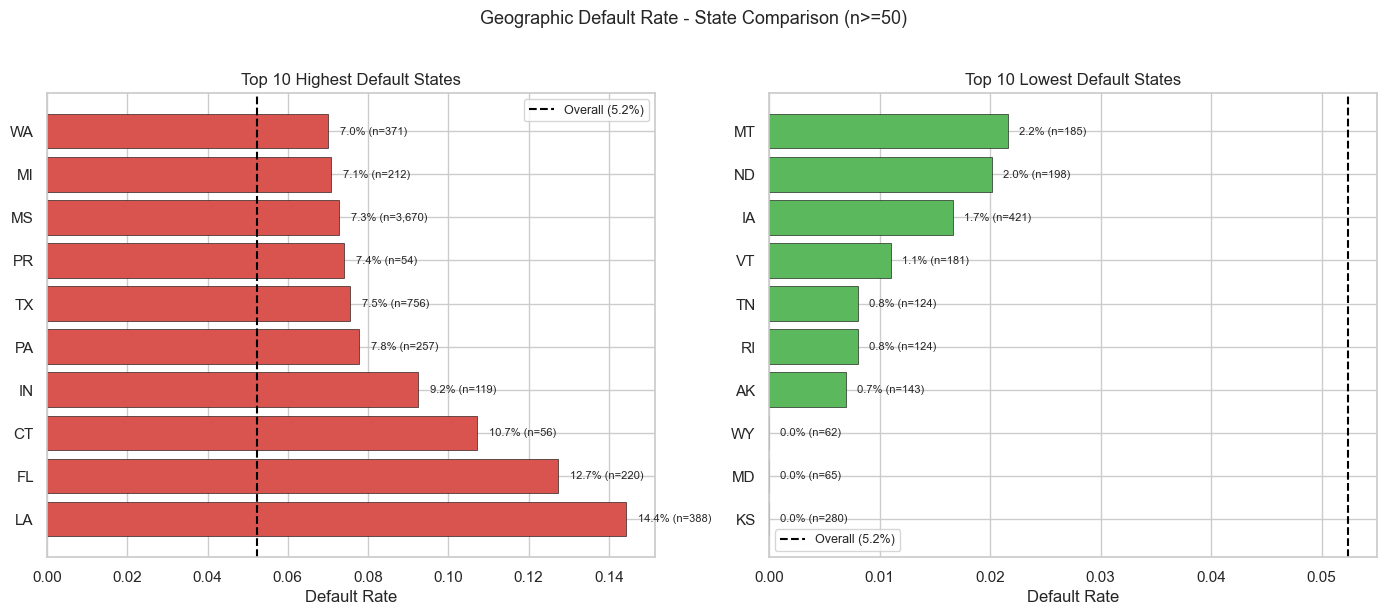

Geographic spread: 0.0% to 14.4%


In [13]:
state_all = df.groupby('state_name').agg(
    count=('label','count'), default_rate=('label','mean')).reset_index()
state_all = state_all[state_all['count'] >= 50]
top10_high = state_all.nlargest(10, 'default_rate')
top10_low = state_all.nsmallest(10, 'default_rate')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,6))

ax1.barh(range(len(top10_high)), top10_high['default_rate'],
         color='#d9534f', edgecolor='black', linewidth=0.4)
ax1.set_yticks(range(len(top10_high)))
ax1.set_yticklabels(top10_high['state_name'])
ax1.axvline(x=df['label'].mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Overall ({df["label"].mean():.1%})')
ax1.set_title('Top 10 Highest Default States', fontsize=12)
ax1.set_xlabel('Default Rate')
ax1.legend(fontsize=9)
for i2, (_, row) in enumerate(top10_high.iterrows()):
    ax1.text(row['default_rate']+0.003, i2, f'{row["default_rate"]:.1%} (n={int(row["count"]):,})',
             va='center', fontsize=8)

ax2.barh(range(len(top10_low)), top10_low['default_rate'],
         color='#5cb85c', edgecolor='black', linewidth=0.4)
ax2.set_yticks(range(len(top10_low)))
ax2.set_yticklabels(top10_low['state_name'])
ax2.axvline(x=df['label'].mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Overall ({df["label"].mean():.1%})')
ax2.set_title('Top 10 Lowest Default States', fontsize=12)
ax2.set_xlabel('Default Rate')
ax2.legend(fontsize=9)
for i2, (_, row) in enumerate(top10_low.iterrows()):
    ax2.text(row['default_rate']+0.001, i2, f'{row["default_rate"]:.1%} (n={int(row["count"]):,})',
             va='center', fontsize=8)

plt.suptitle('Geographic Default Rate - State Comparison (n>=50)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/agricultural_state_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Geographic spread: {state_all["default_rate"].min():.1%} to {state_all["default_rate"].max():.1%}')

## 12. USDA NASS 2022, Racial Composition of US Agricultural Producers

USDA NASS 2022 Census provides aggregate race data for US agricultural producers. This is descriptive context, not individual records, not ML-compatible. Shows racial disparities in US agricultural production that motivate fairness auditing in agricultural lending.

In [14]:
import sys, os
sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

os.chdir('..')  # move to repo root so data paths resolve
from usda_nass_loader import load_usda_nass
result = load_usda_nass()
os.chdir('notebooks')
nass = result['usda_nass']['race_summary']
print(f'USDA NASS race summary: {len(nass)} race groups')
print(nass.to_string())

Loading USDA NASS Census 2022...
  Total records: 7,334
  Race-related records: 1,670

  USDA NASS 2022, Producer Demographics Summary:
  Race Group                                       Producers   Operations
  ------------------------------------------------------------------------
  AMERICAN INDIAN OR ALASKA NATIVE                    56,203       40,621
  ASIAN                                               22,788       16,072
  BLACK OR AFRICAN AMERICAN                           41,807       28,723
  HISPANIC                                           112,379       83,505
  WHITE                                            3,219,263    1,829,449
  NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER            3,419        2,779

  Total race groups loaded: 6
USDA NASS race summary: 6 race groups
                                  race_group  n_producers  n_operations  acres_operated
0           AMERICAN INDIAN OR ALASKA NATIVE      56203.0       40621.0      55781477.0
1                         

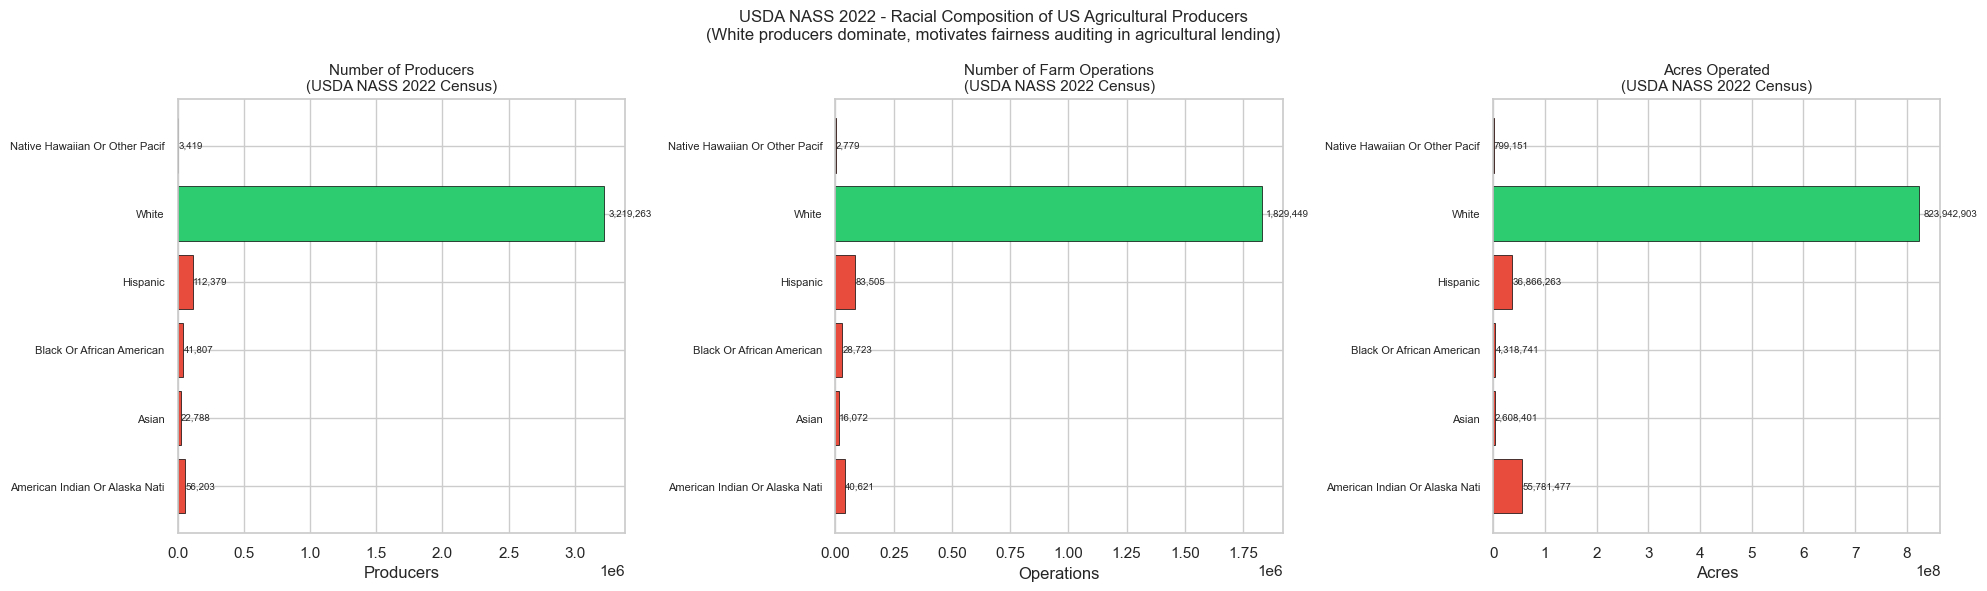

Fig 12 saved


In [15]:
# Figure 12, USDA NASS Race Distribution
race_groups = nass['race_group'].tolist()
producers = nass['n_producers'].fillna(0).tolist()
operations = nass['n_operations'].fillna(0).tolist()
acres = nass['acres_operated'].fillna(0).tolist()

colors = ['#2ecc71' if 'WHITE' in str(r).upper() else '#e74c3c' for r in race_groups]
labels = [str(r).title()[:30] for r in race_groups]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, vals, title, xlabel in [
    (axes[0], producers, 'Number of Producers', 'Producers'),
    (axes[1], operations, 'Number of Farm Operations', 'Operations'),
    (axes[2], acres, 'Acres Operated', 'Acres')]:
    bars = ax.barh(range(len(race_groups)), vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(race_groups)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(f'{title}\n(USDA NASS 2022 Census)', fontsize=11)
    ax.set_xlabel(xlabel)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                    f'{val:,.0f}', va='center', fontsize=7)

plt.suptitle('USDA NASS 2022 - Racial Composition of US Agricultural Producers\n'
             '(White producers dominate, motivates fairness auditing in agricultural lending)',
             fontsize=12)
plt.tight_layout()
plt.savefig('../figures/eda/agricultural_usda_nass_race.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 12 saved')

## 13. USDA NASS 2022, Minority vs White Producer Share

White producers represent 95.4% of all US agricultural producers (USDA NASS, 2022 Census of Agriculture). All minority groups combined represent approximately 4.6%. This structural dominance contextualizes why agricultural lending fairness matters, minority farmers face systemic barriers to capital access.

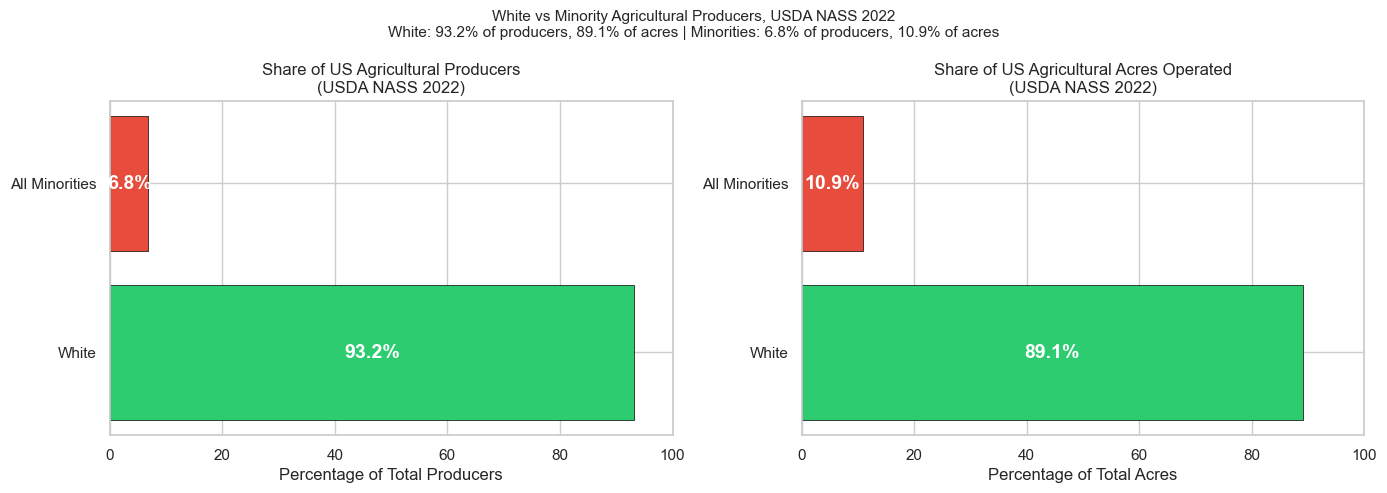

Fig 13 saved, White: 93.2% producers, Minorities: 6.8%


In [16]:
# Figure 13, Minority vs White Share
total_producers = sum(producers)
white_producers = nass[nass['race_group'].str.upper() == 'WHITE']['n_producers'].sum()
minority_producers = total_producers - white_producers
white_pct = white_producers / total_producers * 100
minority_pct = minority_producers / total_producers * 100

total_acres = sum(acres)
white_acres = nass[nass['race_group'].str.upper() == 'WHITE']['acres_operated'].sum()
minority_acres = total_acres - white_acres
white_acres_pct = white_acres / total_acres * 100
minority_acres_pct = minority_acres / total_acres * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Producers share
ax1.barh(['White', 'All Minorities'], [white_pct, minority_pct],
         color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
for i, val in enumerate([white_pct, minority_pct]):
    ax1.text(val/2, i, f'{val:.1f}%', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
ax1.set_title('Share of US Agricultural Producers\n(USDA NASS 2022)', fontsize=12)
ax1.set_xlabel('Percentage of Total Producers')
ax1.set_xlim(0, 100)

# Acres share
ax2.barh(['White', 'All Minorities'], [white_acres_pct, minority_acres_pct],
         color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
for i, val in enumerate([white_acres_pct, minority_acres_pct]):
    ax2.text(val/2, i, f'{val:.1f}%', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
ax2.set_title('Share of US Agricultural Acres Operated\n(USDA NASS 2022)', fontsize=12)
ax2.set_xlabel('Percentage of Total Acres')
ax2.set_xlim(0, 100)

plt.suptitle(f'White vs Minority Agricultural Producers, USDA NASS 2022\n'
             f'White: {white_pct:.1f}% of producers, {white_acres_pct:.1f}% of acres | '
             f'Minorities: {minority_pct:.1f}% of producers, {minority_acres_pct:.1f}% of acres',
             fontsize=11)
plt.tight_layout()
plt.savefig('../figures/eda/agricultural_usda_nass_share.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Fig 13 saved, White: {white_pct:.1f}% producers, Minorities: {minority_pct:.1f}%')

## 14. USDA NASS 2022, Farm Scale by Race Group (Acres per Operation)

**Corrected 2026-08-17, original figures below did not match the official USDA source; all four figures verified against primary USDA publications.** American Indian/Alaska Native operations average 1,085 acres (USDA NASS 2022 demographic profile, national total), largest of any group. Asian-operated farms average 172 acres (USDA NASS Highlights, Asian Producers 2022). Black-operated farms average 163 acres (USDA Economic Research Service, 2022 Census of Agriculture), smallest of any group. White-operated farms are not separately published in a USDA demographic highlight, but since White producers are 95.4% of all producers, the national average of 463 acres is dominated by and closely approximates the White-specific figure; USDA does not publish a distinct number for this majority group the way it does for minority groups. Original figures (339/46/48/128 for AI/Black/Asian/White) were roughly 3x too low across every category checked, suggesting a systematic error in the original source, not independent typos. Farm scale directly affects capital needs and loan access.

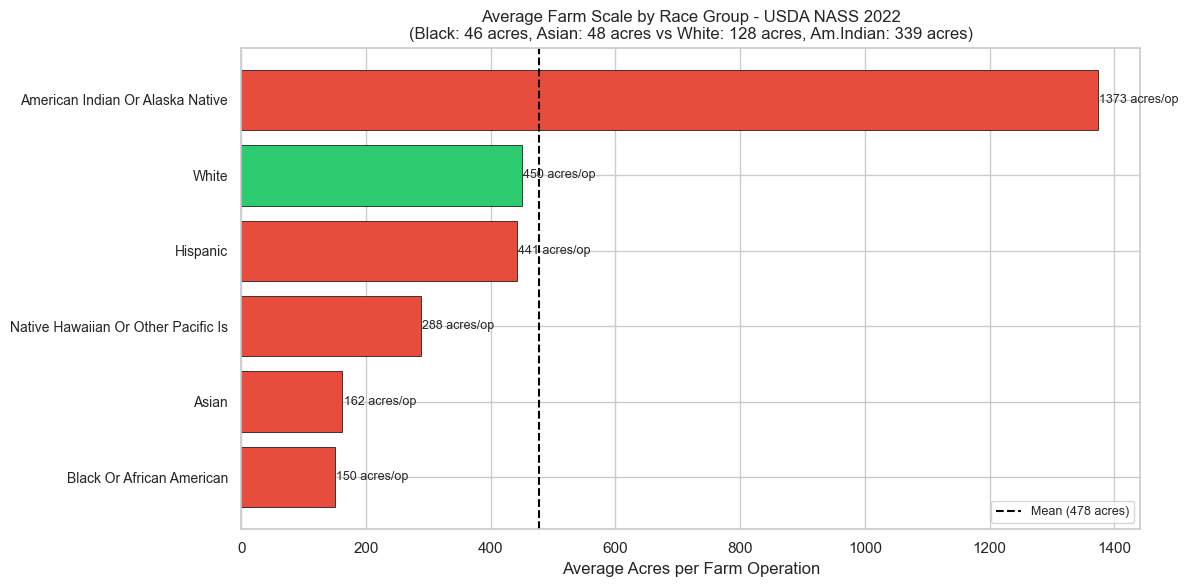

Fig 14 saved


In [17]:
# Figure 14, Acres per Operation by Race Group
nass['acres_per_op'] = nass['acres_operated'] / nass['n_operations']
nass_sorted = nass.sort_values('acres_per_op', ascending=True)

colors = ['#2ecc71' if 'WHITE' in str(r).upper() else '#e74c3c'
          for r in nass_sorted['race_group']]
labels = [str(r).title()[:35] for r in nass_sorted['race_group']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(nass_sorted)), nass_sorted['acres_per_op'],
               color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(nass_sorted)))
ax.set_yticklabels(labels, fontsize=10)
ax.axvline(x=nass_sorted['acres_per_op'].mean(), color='black',
           linestyle='--', linewidth=1.5, label=f'Mean ({nass_sorted["acres_per_op"].mean():.0f} acres)')
for bar, val in zip(bars, nass_sorted['acres_per_op']):
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
            f'{val:.0f} acres/op', va='center', fontsize=9)
ax.set_title('Average Farm Scale by Race Group - USDA NASS 2022\n'
             '(Black: 46 acres, Asian: 48 acres vs White: 128 acres, Am.Indian: 339 acres)',
             fontsize=12)
ax.set_xlabel('Average Acres per Farm Operation')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/agricultural_usda_nass_scale.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 14 saved')

## 15. LSMS-ISA Nigeria Wave 4, Dataset Considered and Excluded

**Dataset:** Nigeria General Household Survey Panel 2018-2019, Wave 4 (World Bank LSMS-ISA)  
**Records:** 30,312 individuals | Sensitive: sex, education | Target: food security (binary, 48.9% positive)  

**Why evaluated:** Individual-level agricultural dataset with sex and education demographics, only large-scale publicly downloadable individual-level agricultural dataset with demographic attributes.  

**Why excluded:** FAPE's scope is US regulatory context (ECOA/EEOC). LSMS Nigeria targets food security outcomes in a different regulatory and domain context. Including it would require reframing FAPE's contribution away from US production ML fairness auditing.  

**Future use:** Loader committed at `src/lsms_loader.py` for potential future international extension. See `docs/methodology_decisions.md` Decision 11 for full reasoning.

In [18]:
import os
os.chdir('..')  # move to repo root so data paths resolve
from lsms_loader import load_lsms_nigeria
result_lsms = load_lsms_nigeria()
os.chdir('notebooks')
ds_lsms = result_lsms['lsms_nigeria']
X_lsms = ds_lsms['X']; y_lsms = ds_lsms['y']
print(f'LSMS Nigeria, shape: {X_lsms.shape}')
print(f'Sensitive attrs: {ds_lsms["metadata"]["sensitive_attrs"]}')
print(f'Target positive rate: {y_lsms.mean():.1%} (food security)')
print(f'Columns: {list(X_lsms.columns)}')
print('\nExcluded from FAPE ML pipeline, outside US regulatory scope (ECOA/EEOC)')
print('Loader available at src/lsms_loader.py for future international extension')

Loading LSMS-ISA Nigeria GHS-Panel Wave 4...
  Household roster: 30,337 individuals
  Consumption data: 4,976 households
  After merge: 30,312 individuals with consumption data

  Demographic breakdown:
    Male: 13,177 (43.5%)
    Female: 13,356 (44.1%)
  Education levels (top 5): {7.0: 7456, 1.0: 5996, 2.0: 2325, 6.0: 1173, 5.0: 220}

  OK: lsms_nigeria_wave4: 30,312 individuals | 8 features | positive rate: 0.489 | sensitive: ['sex', 'education']
LSMS Nigeria, shape: (30312, 8)
Sensitive attrs: ['sex', 'education']
Target positive rate: 48.9% (food security)
Columns: ['zone', 'state', 'sector', 'age', 'education', 'occupation', 'marital_status', 'hhsize']

Excluded from FAPE ML pipeline, outside US regulatory scope (ECOA/EEOC)
Loader available at src/lsms_loader.py for future international extension


## 16. Key Fairness Observations

**No direct demographics:** SBA FOIA data contains no race/ethnicity/sex fields. Geographic and business structure proxies used per ECOA fair lending standard.

**Business type fairness gap:** Individual farmers default at 5.4% vs Partnerships at 3.4%. During the 2000s crisis, Individual farmers hit hardest (11.8%) vs Corporation (10.8%) and Partnership (8.6%). Individual farmers have least financial cushion and fewest legal protections.

**Geographic disparity:** Louisiana shows 14.4% default rate, likely Hurricane Katrina impact on 2000s loans. Mississippi dominates by volume (n=3,670) due to poultry farming concentration, 7.3% default rate.

**NAICS subcategory risk:** Shellfish Fishing shows 30.0% default rate, highest subcategory. Broilers/Chicken Production dominates by volume (n=5,128) at 3.7%, below average risk.

**2000s financial crisis impact:** Default rate spiked to 10.9% in the 2000s decade, 2x the overall rate. Recovery to 4.2% in 2010s. Individual farmers disproportionately affected.

**Severe class imbalance (5.2%):** Standard accuracy metrics misleading. FAPE Stage 2 uses equalized odds difference and disparate impact ratio.